# Sentiment Analysis of Reviews
****
## Lilian Nguyen
### 4/29/25
****
## Problem
#### In the project I am trying to understand how people feel about restaurants in New York specifically NY. I need to use Yelp Fusion API to gather reviews, clean them, and perform analysis to show what the result are.

## Solution
#### Using Yelp Fusion API, I got 60 reviews from 20 restaurants. I cleaned the text, got rid of stopwords, and used sentiment analysis tools. I then visualized the cleaned data through a pie chart and word clouds.

## Question
#### What is the sentiment in Yelp reviews for restaurants in New York, and how does it change when using different sentiment analysis tools?

##### References:
##### The Yelp Fusion sample code
##### Used ChatGPT to fix errors I could not figure out
##### https://www.geeksforgeeks.org/generating-word-cloud-python/
##### https://www.geeksforgeeks.org/removing-stop-words-nltk-python/ 


In [79]:
!pip install textblob wordcloud

In [9]:
#Setting up and importing packages for YELP API
import requests
import pandas as pd

#REPLACE KEY!
#Insert API Key 
API_KEY = "REPLACE WITH KEY"
HEADER = {"Authorization": f"Bearer {API_KEY}"} 

#Function to search for businesses
def searchb(term, location, limit=20, offset=0):
    url = "https://api.yelp.com/v3/businesses/search"
    param = {"term": term, "location": location, "limit": limit}
    response= requests.get(url, headers=HEADER, params=param)
    return response.json().get("businesses", [])

#Function to get the reviews for a specific business
def getreviews(business_id):
    url = f"https://api.yelp.com/v3/businesses/{business_id}/reviews"
    response = requests.get(url, headers = HEADER)
    return [review["text"] for review in response.json().get("reviews", [])]

#Searching for New York restaurants
businesses = searchb("restaurant", "New York, NY", limit=20)
#Getting all the reviews
allreviews= []
offset = 0

for business in businesses:
    allreviews.extend(getreviews(business["id"]))

#Creating a dataframe
dfreviews = pd.DataFrame({"review":allreviews})
print(f"Reviews amount: {len(dfreviews)}")
dfreviews.head()


Reviews amount: 60


,review
0,This restaurant is beautiful and a must visit ...
1,The reason I gave this place a 3 was because t...
2,If you want a vibrant happy hour that's laced ...
3,The energy in this place is great. It's loud s...
4,"Stopped in, Mediterranean food with a twist - ..."


In [11]:
#Cleaning the dataframe
import re
import nltk
from nltk.corpus import stopwords

#Downloading a list of stop words (articles, conjunctions, common verbs, etc.)
nltk.download("stopwords")
stop = set(stopwords.words("english"))

#Cleaning reviews by removing URLs and non letters, making everything lowercase, and then removing the stopwords
def cleantext(text):
    text = re.sub(r"http\S+|www\S+|[^a-zA-Z\s]", "", text)
    text = text.lower()
    text = " ".join(word for word in text.split() if word not in stop)
    return text

#Applying the cleaning and making sure it worked
dfreviews["cleaned"] = dfreviews["review"].apply(cleantext)
dfreviews.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lilyn\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review,cleaned
0,This restaurant is beautiful and a must visit ...,restaurant beautiful must visit youre area ser...
1,The reason I gave this place a 3 was because t...,reason gave place main thing went serving time...
2,If you want a vibrant happy hour that's laced ...,want vibrant happy hour thats laced ambiance s...
3,The energy in this place is great. It's loud s...,energy place great loud dont expect quiet dinn...
4,"Stopped in, Mediterranean food with a twist - ...",stopped mediterranean food twist hudson yards ...


In [13]:
#Performing sentiment analysis
import nltk
nltk.download("movie_reviews")
nltk.download("punkt")

from textblob import TextBlob
from textblob.sentiments import NaiveBayesAnalyzer

#Function for textblob sentiment
def tbsentiment(text):
    blob = TextBlob(text)
    p = blob.sentiment.polarity
    if p > 0:
        return "Positive"
    elif p < 0:
        return "Negative"
    else:
        return "Neutral"

#Function for NaiveBayesAnalyzer sentiment
def nbsentiment(text):
    blob = TextBlob(text, analyzer = NaiveBayesAnalyzer())
    return "Positive" if blob.sentiment.classification == "pos" else "Negative"

#Applying the sentiment analysis to the cleaned dataframe
dfreviews["tbsentiment"] = dfreviews["cleaned"].apply(tbsentiment)
dfreviews["nbsentiment"] = dfreviews["cleaned"].apply(nbsentiment)

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\lilyn\AppData\Roaming\nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lilyn\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


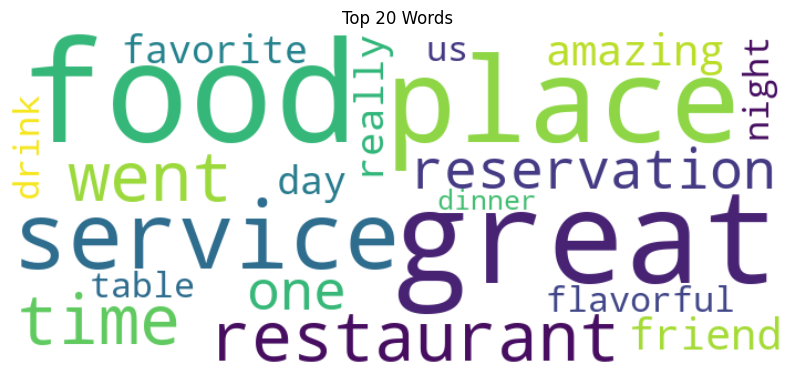

In [15]:
#Creating wordcloud
from wordcloud import WordCloud
import matplotlib.pyplot as plt

#Combining all reviews into one big string
t = " ".join(dfreviews["cleaned"])
#Creating the wordcloud object
wordcloud = WordCloud(width=700, height=300, max_words=20, background_color="white")

#Generating the wordcloud from the big string
wordcloud.generate(t)

#Plotting the wordcloud
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Top 20 Words")
plt.show()


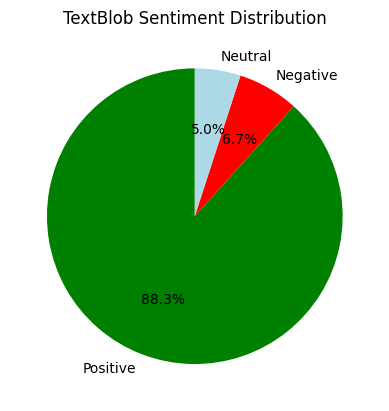

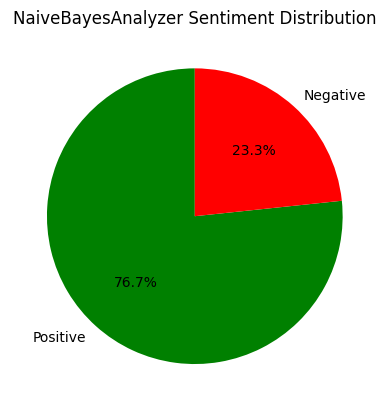

In [14]:
#Donut chart for TextBlob and NaiveBayesAnalyzer sentiment analysis
import matplotlib.pyplot as plt

#Creating a default pie chart
def donut(labels, sizes, title):
    colors = ["green", "red", "lightblue"]
    fig, ax = plt.subplots()
    ax.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=90, colors=colors)
    ax.set_title(title)
    plt.show()

#Creating the TextBlob donut
tbdonut = dfreviews["tbsentiment"].value_counts()
donut(tbdonut.index.tolist(), tbdonut.tolist(), "TextBlob Sentiment Distribution")
#Creating the NaiveBayesAnalyzer donut
nbdonut = dfreviews["nbsentiment"].value_counts()
donut(nbdonut.index.tolist(), nbdonut.tolist(), "NaiveBayesAnalyzer Sentiment Distribution")

## Conclusion
****
- TextBlob found that most of the reviews were positive, with only a small portion of them being negative and neutral
- NaiveBayesAnalyzer showed a bigger count of negative reviews compared to TextBlob.
#### This shows that sentiment analysis can differ depending on which method is used
****
#### The word cloud also showed the most common words relating to the atmosphere and service.